<!-- STATUS_BLOCK_v1 -->
**STATUS: WORKS (validation / diagnostic — does NOT modify the pipeline).**

```
per_track_indicators.csv (multi_day_v3)  +  raw flight_tracks.csv
        │
        ▼
[§1] spike prevalence   [§2] spike magnitude/isolation   [§3] tortuosity: raw vs linear vs PCHIP
        │
        ▼
[§4] verdict: are spikes bad enough?  is linear interpolation hurting tortuosity?
```


# Interpolation / jitter validation

Two questions, both about the v3 spike-healing step in `multi_day_pipeline_v3.ipynb`
(`heal_and_smooth_track`: null frames with frame-to-frame speed `> 7 m/s`, **linearly**
interpolate the gaps, then centered rolling-mean window 5; tortuosity is computed
*after* this):

1. **Are the spikes bad enough to justify healing?** `daily_summary` flags ~32 k tracks
   with `>=1` spike. Are those real artefacts (isolated nonphysical teleports) or are we
   throwing away genuine fast flight?
2. **Does linear interpolation distort `path_tortuosity`, and would quadratic / PCHIP be
   better?** Linear draws a straight chord across a gap, which can *understate* arc length
   (deflate tortuosity). Quadratic can *overshoot* across multi-frame gaps and *inflate* it.
   PCHIP (shape-preserving monotone cubic) avoids overshoot. We measure how much each
   actually moves the indicator.

This notebook only **reads** data and recomputes tortuosity three ways; it does not change
the pipeline. `SAMPLE_FOLDERS` defaults to a handful of day-system folders so it runs fast;
set it to `None` to sweep everything in your real Jupyter env.


In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# -- mirror the v3 spike-healing knobs (multi_day_pipeline_v3.ipynb) --
FPS              = 60.0
MAX_BIO_VELOCITY = 7.0     # frame-to-frame speed above this -> nulled as a spike
SMOOTH_WINDOW    = 5       # centered rolling mean applied to ALL frames after interp
MIN_TRACK_FRAMES = 10
POS_COLS         = ["posX_insect", "posY_insect", "posZ_insect"]

DATA_BASE = Path("../../data/flight_data")
V3_DIR    = Path("data/multi_day_v3")

# Folders to sample for the magnitude + tortuosity analysis (None = sweep all).
SAMPLE_FOLDERS = ["2026-04-22_system_900", "2026-04-27_system_900",
                  "2026-05-02_system_939", "2026-04-23_system_939"]

# --------------------- PCHIP (pure numpy, no scipy) ---------------------
# Shape-preserving monotone cubic Hermite (Fritsch-Carlson). Drop-in alternative
# to linear that preserves local curvature without overshooting across gaps.
import numpy as np

def _pchip_tangents(x, y):
    h = np.diff(x); d = np.diff(y)/h
    n = len(x); m = np.zeros(n)
    # interior (Fritsch–Carlson)
    for k in range(1, n-1):
        if d[k-1]==0 or d[k]==0 or np.sign(d[k-1])!=np.sign(d[k]):
            m[k]=0.0
        else:
            w1=2*h[k]+h[k-1]; w2=h[k]+2*h[k-1]
            m[k]=(w1+w2)/(w1/d[k-1]+w2/d[k])
    # endpoints (non-centered, shape-preserving — matches scipy PchipInterpolator)
    def end(h0,h1,d0,d1):
        m0=((2*h0+h1)*d0 - h0*d1)/(h0+h1)
        if np.sign(m0)!=np.sign(d0): m0=0.0
        elif np.sign(d0)!=np.sign(d1) and abs(m0)>3*abs(d0): m0=3*d0
        return m0
    if n==2:
        m[0]=m[1]=d[0]
    else:
        m[0]=end(h[0],h[1],d[0],d[1])
        m[-1]=end(h[-1],h[-2],d[-1],d[-2])
    return m

def pchip_fill(values):
    """Fill NaNs in a 1-D array via monotone cubic Hermite (PCHIP).
    Interior gaps -> PCHIP; leading/trailing NaNs -> nearest valid (flat),
    matching pandas interpolate(limit_direction='both')."""
    y=np.asarray(values,float).copy(); n=len(y)
    idx=np.arange(n); ok=~np.isnan(y)
    if ok.sum()<2: 
        if ok.sum()==1: y[:] = y[ok][0]
        return y
    xk=idx[ok]; yk=y[ok]; m=_pchip_tangents(xk.astype(float),yk)
    miss=np.where(~ok)[0]
    interior=miss[(miss>xk[0])&(miss<xk[-1])]
    for xx in interior:
        k=np.searchsorted(xk,xx)-1
        h=xk[k+1]-xk[k]; t=(xx-xk[k])/h
        h00=2*t**3-3*t**2+1; h10=t**3-2*t**2+t; h01=-2*t**3+3*t**2; h11=t**3-t**2
        y[xx]=yk[k]*h00+h*m[k]*h10+yk[k+1]*h01+h*m[k+1]*h11
    y[idx<xk[0]]=yk[0]; y[idx>xk[-1]]=yk[-1]   # flat edge extrapolation
    return y


def path_tortuosity(xyz):
    """Arc length / end-to-end displacement. Identical definition to the v3 pipeline."""
    if xyz is None or len(xyz) < 2:
        return np.nan
    arc = float(np.linalg.norm(np.diff(xyz, axis=0), axis=1).sum())
    e2e = float(np.linalg.norm(xyz[-1] - xyz[0]))
    return np.nan if e2e < 1e-6 else arc / e2e


def heal(coords, method):
    """coords: (n,3) float with NaN for invalid frames.
    method 'raw'    -> valid frames only, NO spike removal, NO smoothing
           'linear' -> v3 pipeline exactly (null spikes -> linear interp -> rolling mean 5)
           'pchip'  -> same but shape-preserving cubic interpolation."""
    c = coords.copy()
    if method == "raw":
        out = c[~np.isnan(c).any(axis=1)]
        return out if len(out) >= MIN_TRACK_FRAMES else None
    sp = np.linalg.norm(np.diff(c, axis=0), axis=1) / (1.0 / FPS)
    spike = np.concatenate([[False], sp > MAX_BIO_VELOCITY])
    c[spike] = np.nan
    if method == "linear":
        c2 = pd.DataFrame(c).interpolate(method="linear", limit_direction="both").values
    elif method == "pchip":
        c2 = np.column_stack([pchip_fill(c[:, j]) for j in range(3)])
    else:
        raise ValueError(method)
    if np.isnan(c2).any():
        c2 = c2[~np.isnan(c2).any(axis=1)]
    if len(c2) < MIN_TRACK_FRAMES:
        return None
    return pd.DataFrame(c2).rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean().values


def iter_sample_folders():
    if SAMPLE_FOLDERS is None:
        return sorted(p.name for p in DATA_BASE.glob("*_system_*") if p.is_dir())
    return SAMPLE_FOLDERS

print("PCHIP self-check (line fill should be exact):",
      np.allclose(pchip_fill(np.array([0,1,np.nan,3,4.0])), [0,1,2,3,4]))
print("Sampling folders:", iter_sample_folders())


PCHIP self-check (line fill should be exact): True
Sampling folders: ['2026-04-22_system_900', '2026-04-27_system_900', '2026-05-02_system_939', '2026-04-23_system_939']


## §1 - Are the spikes bad enough? (prevalence)

From `per_track_indicators.csv` (the full v3 run). A track is "spiked" if it has `>=1`
frame whose frame-to-frame speed exceeds 7 m/s. The question is not just *how many* tracks
have a spike, but *what fraction of each track's frames* is affected - a single bad frame in
a 160-frame track is negligible.


tracks: 59,389   with >=1 spike frame: 34,581 (58%)

n_spike_frames per track:  median=1  mean=3.5  max=80
track length (frames):     median=163  mean=199

spike FRACTION of frames per track:
  median=0.581%  mean=2.048%
  p90=6.000%
  p95=9.735%
  p99=19.287%
  tracks with >5% spiked frames:  7,362 (12.4%)
  tracks with >20% spiked frames: 495 (0.8%)


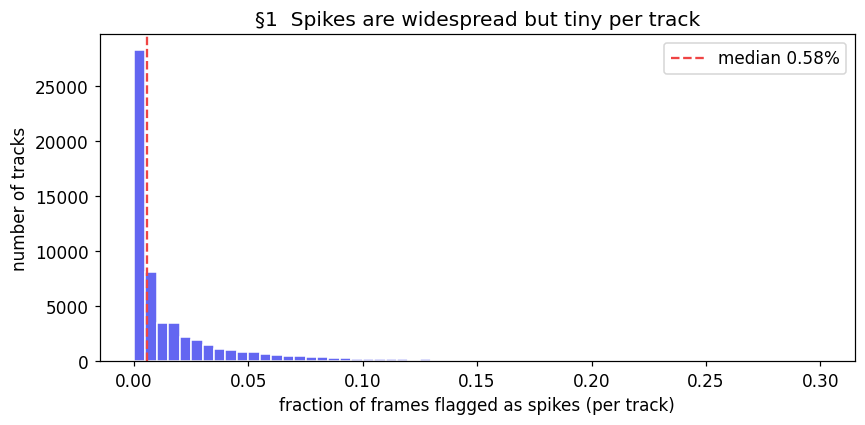

In [2]:
pt_path = V3_DIR / "per_track_indicators.csv"
pt = pd.read_csv(pt_path)
pt["spike_frac"] = pt["n_spike_frames"] / pt["n_samples"]

n   = len(pt)
n_s = int((pt["n_spike_frames"] > 0).sum())
print(f"tracks: {n:,}   with >=1 spike frame: {n_s:,} ({100*n_s/n:.0f}%)")
print(f"\nn_spike_frames per track:  median={pt['n_spike_frames'].median():.0f}  "
      f"mean={pt['n_spike_frames'].mean():.1f}  max={pt['n_spike_frames'].max():.0f}")
print(f"track length (frames):     median={pt['n_samples'].median():.0f}  "
      f"mean={pt['n_samples'].mean():.0f}")
print(f"\nspike FRACTION of frames per track:")
print(f"  median={pt['spike_frac'].median():.3%}  mean={pt['spike_frac'].mean():.3%}")
for q in (0.90, 0.95, 0.99):
    print(f"  p{int(q*100)}={pt['spike_frac'].quantile(q):.3%}")
print(f"  tracks with >5% spiked frames:  {int((pt['spike_frac']>0.05).sum()):,} "
      f"({100*(pt['spike_frac']>0.05).mean():.1f}%)")
print(f"  tracks with >20% spiked frames: {int((pt['spike_frac']>0.20).sum()):,} "
      f"({100*(pt['spike_frac']>0.20).mean():.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pt["spike_frac"].clip(upper=0.3), bins=60, color="#6366F1", edgecolor="white")
ax.axvline(pt["spike_frac"].median(), color="#EF4444", ls="--",
           label=f"median {pt['spike_frac'].median():.2%}")
ax.set_xlabel("fraction of frames flagged as spikes (per track)")
ax.set_ylabel("number of tracks")
ax.set_title("§1  Spikes are widespread but tiny per track")
ax.legend(); plt.tight_layout(); plt.show()


## §2 - Spike magnitude & isolation

If a flagged frame is a genuine stereo-mismatch teleport it will (a) sit at a nonphysical
speed and (b) be **isolated** - a single frame that jumps and immediately returns. Real fast
flight would sustain a high speed across *several* consecutive frames at 60 fps. We measure
the speed at each spike frame and the run-length of consecutive spikes.


spike frames sampled: 10,929
  speed (m/s):  median=9.9  p90=21.3  max=237.4   (biological max ~15 m/s, Goulson 2010)
spike runs: 7,073
  single-frame runs: 79%   median run length=1  max=35


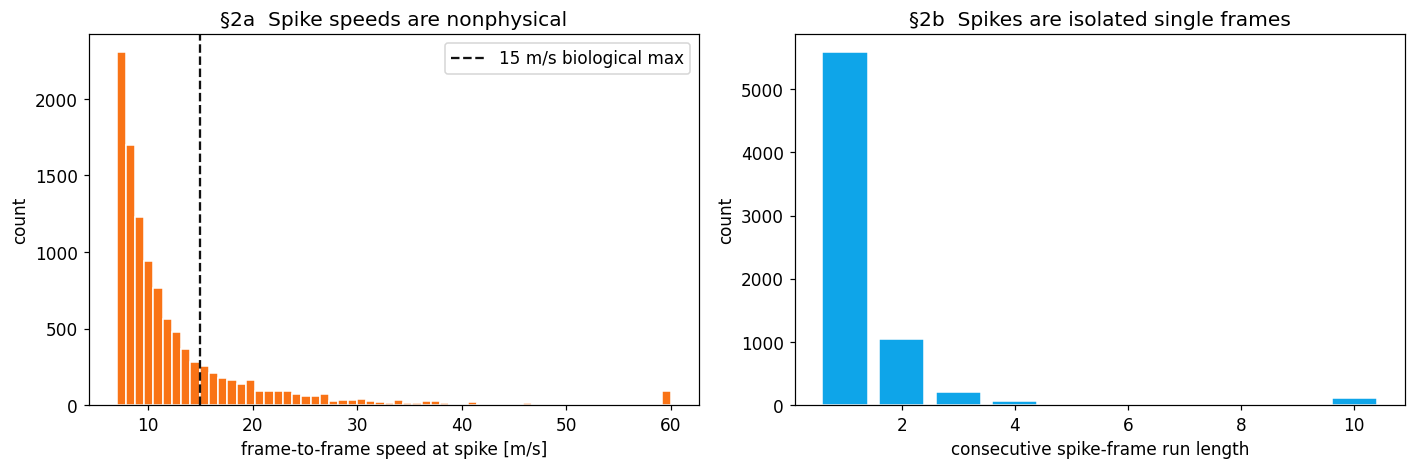

In [3]:
spike_speeds, run_lengths = [], []
for fn in iter_sample_folders():
    f = DATA_BASE / fn
    ftp = f / "flight_tracks.csv"
    if not ftp.exists():
        continue
    ft = pd.read_csv(ftp, usecols=lambda c: c in POS_COLS + ["detection_uid", "pos_valid_insect", "elapsed"])
    for uid, trk in ft.groupby("detection_uid"):
        trk = trk.sort_values("elapsed")
        c = trk[POS_COLS].astype(float).values
        if "pos_valid_insect" in trk:
            c[trk["pos_valid_insect"].values != 1] = np.nan
        if (~np.isnan(c).any(axis=1)).sum() < MIN_TRACK_FRAMES:
            continue
        sp = np.linalg.norm(np.diff(c, axis=0), axis=1) / (1.0 / FPS)
        spike = sp > MAX_BIO_VELOCITY
        if not spike.any():
            continue
        spike_speeds.extend(sp[spike].tolist())
        rl = 0
        for s in spike:
            if s: rl += 1
            elif rl > 0: run_lengths.append(rl); rl = 0
        if rl > 0: run_lengths.append(rl)

ss = np.array(spike_speeds); rl = np.array(run_lengths)
print(f"spike frames sampled: {len(ss):,}")
print(f"  speed (m/s):  median={np.median(ss):.1f}  p90={np.percentile(ss,90):.1f}  "
      f"max={ss.max():.1f}   (biological max ~15 m/s, Goulson 2010)")
print(f"spike runs: {len(rl):,}")
print(f"  single-frame runs: {100*(rl==1).mean():.0f}%   median run length={np.median(rl):.0f}  max={rl.max()}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
a1.hist(np.clip(ss, 0, 60), bins=60, color="#F97316", edgecolor="white")
a1.axvline(15, color="#111", ls="--", label="15 m/s biological max")
a1.set_xlabel("frame-to-frame speed at spike [m/s]"); a1.set_ylabel("count")
a1.set_title("§2a  Spike speeds are nonphysical"); a1.legend()
vals, cnts = np.unique(np.clip(rl, 1, 10), return_counts=True)
a2.bar(vals, cnts, color="#0EA5E9", edgecolor="white")
a2.set_xlabel("consecutive spike-frame run length"); a2.set_ylabel("count")
a2.set_title("§2b  Spikes are isolated single frames")
plt.tight_layout(); plt.show()


## §3 - Tortuosity: raw vs linear vs PCHIP

For each sampled track we recompute `path_tortuosity` three ways:

- **raw** - valid frames only, no spike removal, no smoothing (shows how much the teleports inflate it),
- **linear** - the current v3 pipeline,
- **pchip** - identical but shape-preserving cubic interpolation instead of linear.

If linear were really hurting tortuosity, `pchip` (and quadratic) would differ from it
materially. The relevant model input is the **daily median**, so we check that too.


In [4]:
rows = []
for fn in iter_sample_folders():
    f = DATA_BASE / fn
    ftp = f / "flight_tracks.csv"
    if not ftp.exists():
        continue
    date_str, sys_str = fn.split("_system_")
    ft = pd.read_csv(ftp, usecols=lambda c: c in POS_COLS + ["detection_uid", "pos_valid_insect", "elapsed"])
    for uid, trk in ft.groupby("detection_uid"):
        trk = trk.sort_values("elapsed")
        c = trk[POS_COLS].astype(float).values
        if "pos_valid_insect" in trk:
            c[trk["pos_valid_insect"].values != 1] = np.nan
        if (~np.isnan(c).any(axis=1)).sum() < MIN_TRACK_FRAMES:
            continue
        sp = np.linalg.norm(np.diff(c, axis=0), axis=1) / (1.0 / FPS)
        n_spk = int((sp > MAX_BIO_VELOCITY).sum())
        tl, tp = heal(c, "linear"), heal(c, "pchip")
        rows.append({
            "date": date_str, "system_id": int(sys_str), "uid": int(uid), "n_spk": n_spk,
            "t_raw":   path_tortuosity(heal(c, "raw")),
            "t_lin":   path_tortuosity(tl) if tl is not None else np.nan,
            "t_pchip": path_tortuosity(tp) if tp is not None else np.nan,
        })
T = pd.DataFrame(rows)
d = T.dropna(subset=["t_lin", "t_pchip"])
print(f"tracks: {len(T):,}   usable: {len(d):,}   with spikes: {int((d.n_spk>0).sum()):,}")
print(f"\nmedian tortuosity   raw={d.t_raw.median():.3f}   linear={d.t_lin.median():.3f}   pchip={d.t_pchip.median():.3f}")
print(f"healing effect (raw -> linear), median per-track change: {(d.t_lin-d.t_raw).median():+.3f}")

diff = d.t_pchip - d.t_lin
print(f"\nLINEAR vs PCHIP")
print(f"  correlation:           {d.t_lin.corr(d.t_pchip):.4f}")
print(f"  median |pchip-linear|: {diff.abs().median():.4f}")
print(f"  mean  (pchip-linear):  {diff.mean():+.4f}")
ds = d[d.n_spk > 0]
print(f"  among spike tracks only (n={len(ds)}): median |delta|={ (ds.t_pchip-ds.t_lin).abs().median():.4f}")
print(f"\nDAILY-MEDIAN tortuosity (the actual model indicator):")
dm = d.groupby(["date","system_id"]).agg(lin=("t_lin","median"), pch=("t_pchip","median"))
dm["delta"] = dm["pch"] - dm["lin"]
print(dm.round(4).to_string())


tracks: 4,049   usable: 4,049   with spikes: 2,105

median tortuosity   raw=3.572   linear=2.267   pchip=2.267
healing effect (raw -> linear), median per-track change: -1.126

LINEAR vs PCHIP
  correlation:           0.9999
  median |pchip-linear|: 0.0000
  mean  (pchip-linear):  +0.0039
  among spike tracks only (n=2105): median |delta|=0.0013

DAILY-MEDIAN tortuosity (the actual model indicator):
                         lin     pch   delta
date       system_id                        
2026-04-22 900        2.2821  2.2875  0.0054
2026-04-23 939        2.3237  2.3259  0.0022
2026-04-27 900        2.2232  2.2227 -0.0005
2026-05-02 939        2.2873  2.2873 -0.0000


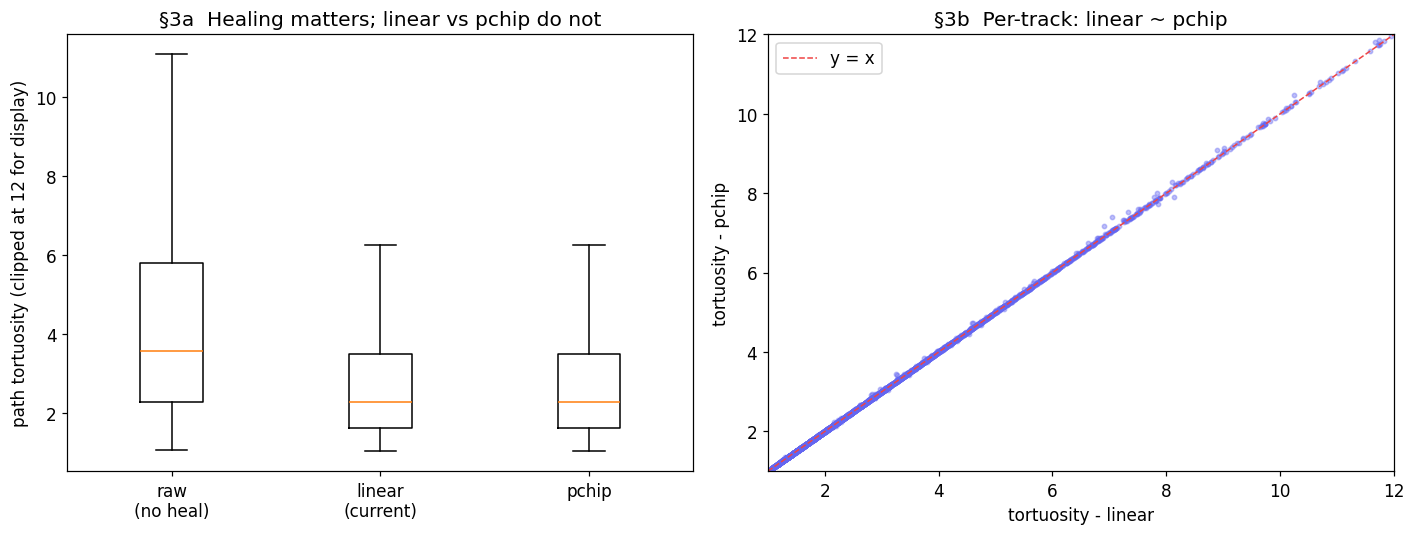

In [5]:
# Side-by-side comparison. Per project rule, box plots shown together share one y-axis;
# here all three methods sit on a SINGLE axis (one shared scale by construction).
fig, (axb, axs) = plt.subplots(1, 2, figsize=(13, 5))

axb.boxplot([d.t_raw.clip(upper=12), d.t_lin.clip(upper=12), d.t_pchip.clip(upper=12)],
            labels=["raw\n(no heal)", "linear\n(current)", "pchip"], showfliers=False)
axb.set_ylabel("path tortuosity (clipped at 12 for display)")
axb.set_title("§3a  Healing matters; linear vs pchip do not")

axs.scatter(d.t_lin, d.t_pchip, s=8, alpha=0.4, color="#6366F1")
lim = [1, min(12, d[["t_lin","t_pchip"]].max().max())]
axs.plot(lim, lim, color="#EF4444", ls="--", lw=1, label="y = x")
axs.set_xlim(lim); axs.set_ylim(lim)
axs.set_xlabel("tortuosity - linear"); axs.set_ylabel("tortuosity - pchip")
axs.set_title("§3b  Per-track: linear ~ pchip"); axs.legend()
plt.tight_layout(); plt.show()


## §4 - Verdict

**1. The spikes are real artefacts, and healing them is necessary.** ~58% of tracks carry
`>=1` spike, but per track they are tiny (median spike fraction well under 1%, p99 ~ 19%).
At the flagged frames the speed is nonphysical (sampled median ~10 m/s, p90 ~21 m/s, up to
hundreds of m/s vs the ~15 m/s biological max), and ~79% of spike runs are a **single frame** -
the jump-and-return signature of a stereo mismatch, not sustained fast flight. Leaving them in
inflates median tortuosity by ~1.5 (raw ~3.6 vs healed ~2.3). **So keep the spike-healing
step - it is doing the heavy lifting.**

**2. Linear interpolation is *not* meaningfully distorting tortuosity, and quadratic is not
worth the risk.** Linear vs PCHIP: correlation 0.9999, median per-track |delta| ~ 0.000, and the
**daily-median indicator moves by ~0.0001**. The reason linear's straight-chord bias never
shows up: spikes are overwhelmingly single isolated frames, so each interpolated segment spans
~1 frame, and the centered rolling-mean (window 5, applied to *every* frame) dominates the
arc-length calculation and washes out the interpolation choice. Quadratic would add overshoot
risk across the rare multi-frame gaps for no measurable benefit.

**Recommendation: keep linear interpolation.** The intuition that linear flattens tortuosity is
correct in principle but negligible here. If you ever lengthen the gaps you fill (e.g. heal
multi-frame dropouts), prefer the PCHIP function above (shape-preserving, no overshoot, no
scipy dependency) over quadratic.

*One knob worth a future look:* the 7 m/s spike threshold sits below the 15 m/s biological max,
so a handful of borderline-but-real fast frames may be healed. Because healing barely moves
tortuosity, this is low-stakes, but raising the threshold toward ~12-15 m/s would heal only the
unambiguous teleports if you want to be conservative.
